# ÉTAPE 2 - Analyse exploratoire ciblée : attrition vs non-attrition

**Objectif :**
Construire un jeu de données prêt pour l’entraînement de modèles de classification supervisée.

**Livrables attendus :**
- Un DataFrame X contenant les features prêtes à être injectées dans un modèle sklearn
- Une Series y correspondant à la variable cible
- Des transformations reproductibles (fonctions Python)

## Imports

In [3]:
import os
import sys

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline

from src.modeling import evaluate_model, save_model
from src.processing import build_preprocessor
from src.visualization import (
    plot_correlation_matrix,
    plot_feature_importance,
    plot_shap_summary,
    plot_shap_waterfall,
)


### Chargement du dataframe

In [4]:
df = pd.read_csv('../data/combined_df.csv')
print("Dataframe chargé depuis '../data/combined_df.csv'")
print("Shape:", df.shape)

Dataframe chargé depuis '../data/combined_df.csv'
Shape: (1470, 33)


## Définition de la cible et suppression des colonnes non exploitables

In [5]:
TARGET = "a_quitte_l_entreprise"

# Colonnes à exclure du ML (fuite de données / post-événement)
LEAK_COLS = [
    TARGET,
    "attrition_numeric",
    "date_depart",
    "motif_depart",
    "statut_depart"
]

# Construction finale de X et y
X = df.drop(columns=[c for c in LEAK_COLS if c in df.columns])
y = df[TARGET].map({'Oui': 1, 'Non': 0}).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Distribution cible:")
print(y.value_counts(normalize=True).round(3))

X shape: (1470, 31)
y shape: (1470,)
Distribution cible:
a_quitte_l_entreprise
0    0.839
1    0.161
Name: proportion, dtype: float64


## Séparation variables numériques / catégorielles

In [6]:
# Transformer la colonne heure_supplementaires en 0 et 1 
X['heure_supplementaires'] = X['heure_supplementaires'].map({'Oui': 1, 'Non': 0}).fillna(0).astype(int)

In [7]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

print('Features numériques :', num_cols)
print('Features catégorielles :', cat_cols)

Features numériques : Index(['nombre_participation_pee', 'nb_formations_suivies',
       'nombre_employee_sous_responsabilite', 'employee_id',
       'distance_domicile_travail', 'niveau_education',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel',
       'age', 'revenu_mensuel', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires'],
      dtype='object')
Features catégorielles : Index(['domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'genre',
       'statut_marital', 'departement', 'poste',
       'augementation_salaire_precedente'],
      dt

## Matrice de corrélation (Pearson)

Constant numeric columns removed: ['nombre_employee_sous_responsabilite', 'nombre_heures_travailless']


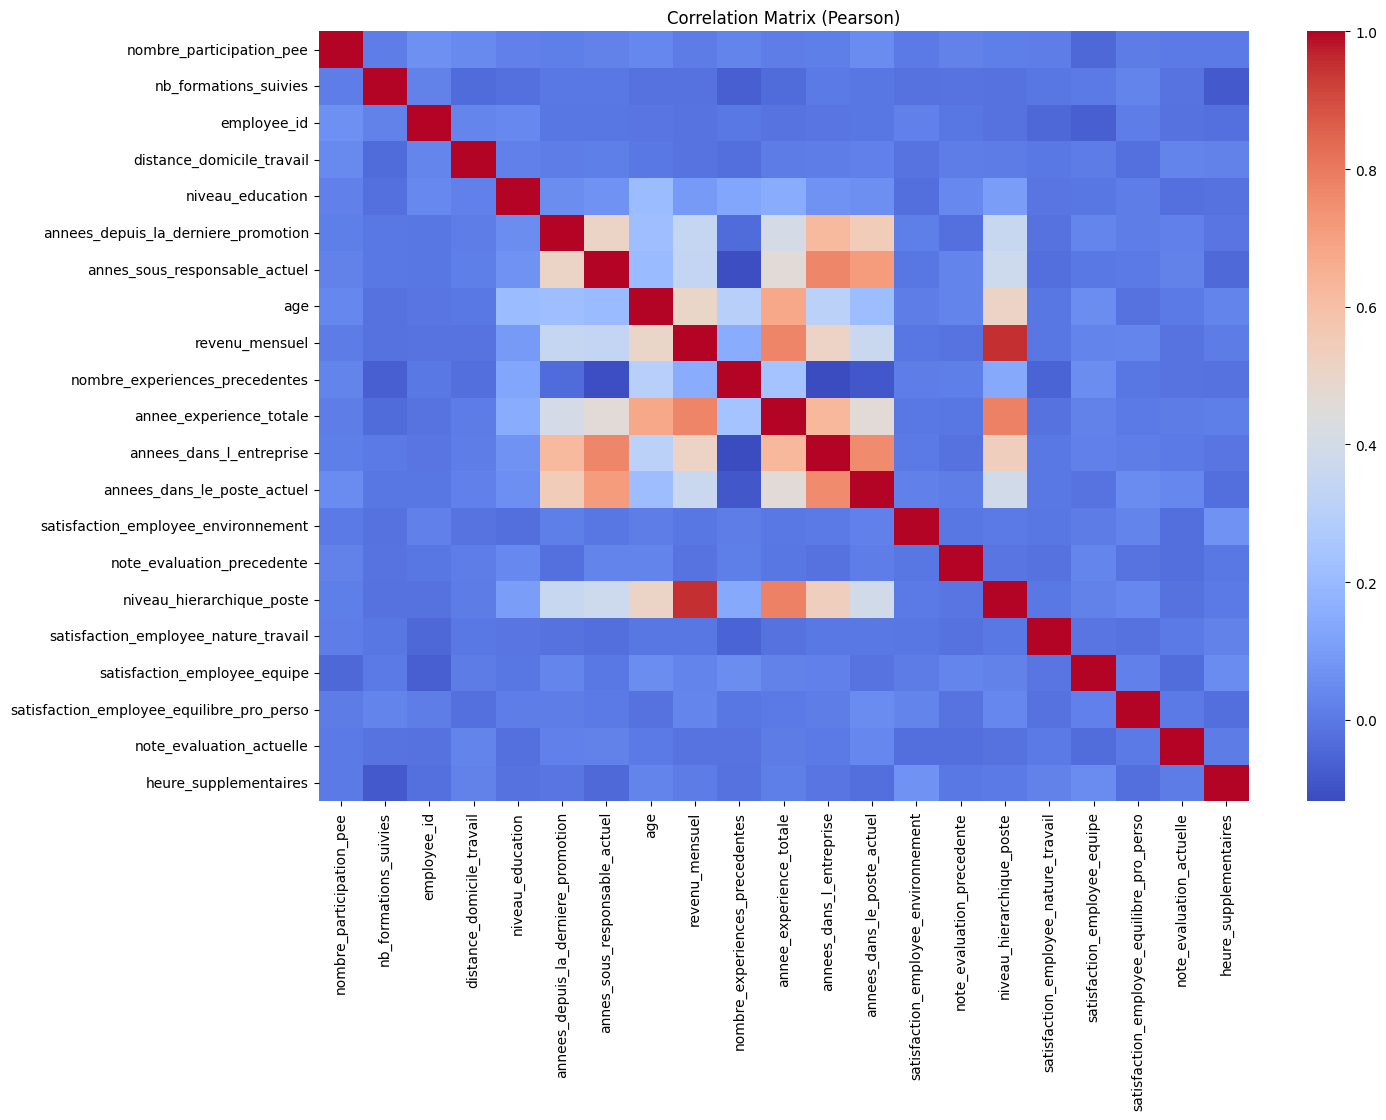

Paires fortement corrélées (> 0.85) :


[('niveau_hierarchique_poste',
  'revenu_mensuel',
  np.float64(0.9502999134798472))]

In [8]:
# Suppression des colonnes constantes (zero variance)
num_cols = X.select_dtypes(include='number').columns
constant_num_cols = [c for c in num_cols if X[c].nunique(dropna=False) <= 1]

print('Constant numeric columns removed:', constant_num_cols)
X_corr = X.drop(columns=constant_num_cols)

# Matrice de corrélation (features numériques uniquement)
num_cols_clean = X_corr.select_dtypes(include='number').columns
plot_correlation_matrix(X_corr[num_cols_clean])

# Détection des fortes corrélations
corr_matrix = X_corr[num_cols_clean].corr(method='pearson').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col]) for col in upper.columns for row in upper.index if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85]

print('Paires fortement corrélées (> 0.85) :')
high_corr_pairs

### Interprétation de la Matrice de Corrélation
1. **Alerte Multicollinéarité (Point Critique) :**
- Il existe une corrélation extrêmement forte (0.95) entre le Revenu Mensuel et le Niveau Hiérarchique.
**Conséquence :** Ces deux variables apportent quasiment la même information au modèle. Pour éviter des biais ou du bruit dans les algorithmes (redondance), il sera probablement nécessaire de n'en conserver qu'une seule des deux pour l'entraînement.
2. **Faibles Corrélations avec la Cible (Attrition) :**
- Le lien direct entre les variables chiffrées et l'attrition reste faible (< 0.20). Aucun indicateur numérique ne suffit à lui seul pour prédire un départ.
3. **Facteurs de Stabilité :**
Les variables de séniorité (Expérience totale, Âge, Années dans le poste) montrent les corrélations les plus notables avec l'attrition. Bien que faibles, elles indiquent une tendance : la stabilité financière et hiérarchique freine généralement les départs.

In [9]:
# Suppression de 'niveau_hierarchique_poste' car très fortement corrélé avec 'revenu_mensuel' (0.95)
# conserver 'revenu_mensuel' (variable continue plus riche).

col_to_drop_corr = ["niveau_hierarchique_poste"]

if set(col_to_drop_corr).issubset(X.columns):
    X = X.drop(columns=col_to_drop_corr)
    print(f"Variable(s) supprimée(s) pour multi-collinéarité : {col_to_drop_corr}")
else:
    print("Variable(s) déjà supprimée(s).")

# Mise à jour des listes de features
num_cols = [c for c in num_cols if c not in col_to_drop_corr]
cat_cols = [c for c in cat_cols if c not in col_to_drop_corr]

print("Shape X après suppression :", X.shape)

Variable(s) supprimée(s) pour multi-collinéarité : ['niveau_hierarchique_poste']
Shape X après suppression : (1470, 30)


In [10]:
for col in num_cols:
    print(col, X[col].unique()[:5])

nombre_participation_pee [0 1 3 2]
nb_formations_suivies [0 3 2 5 1]
nombre_employee_sous_responsabilite [1]
employee_id [1 2 4 5 7]
distance_domicile_travail [ 1  8  2  3 24]
niveau_education [2 1 4 3 5]
annees_depuis_la_derniere_promotion [0 1 3 2 7]
annes_sous_responsable_actuel [5 7 0 2 6]
age [41 49 37 33 27]
revenu_mensuel [5993 5130 2090 2909 3468]
nombre_experiences_precedentes [8 1 6 9 0]
nombre_heures_travailless [80]
annee_experience_totale [ 8 10  7  6 12]
annees_dans_l_entreprise [ 6 10  0  8  2]
annees_dans_le_poste_actuel [4 7 0 2 5]
satisfaction_employee_environnement [2 3 4 1]
note_evaluation_precedente [3 2 4 1]
satisfaction_employee_nature_travail [4 2 3 1]
satisfaction_employee_equipe [1 4 2 3]
satisfaction_employee_equilibre_pro_perso [1 3 2 4]
note_evaluation_actuelle [3 4]
heure_supplementaires [1 0]


Les transformations (imputation, scaling, encodage) sont maintenant regroupées dans la fonction `build_preprocessor` du module `src.processing`.


### Construction finale de X

In [11]:
preprocessor = build_preprocessor(num_cols, cat_cols)

# Transformation (sans modèle)
X_prepared = preprocessor.fit_transform(X)

print("Shape X_prepared :", X_prepared.shape)

Shape X_prepared : (1470, 64)


## Conclusion - Étape 2

À l’issue de cette étape d'exploration et de nettoyage, nous avons abouti à :

1. **Données Nettoyées :** Suppression des identifiants et variables constantes.

2. **Analyse des Corrélations :**
    - Identification d'une forte multicollinéarité (0.95) entre Revenu Mensuel et Niveau Hiérarchique.
    - Action : Suppression de niveau_hierarchique_poste pour ne garder que le revenu (plus informatif).
    - Observation que l'attrition est davantage liée à des facteurs de stabilité (âge, ancienneté) qu'à des critères financiers isolés.

3. **Préparation :** Distinction faite entre features numériques et catégorielles.

**Statut :** Le DataFrame X est désormais optimisé et la cible y isolée. Les données sont prêtes pour la construction du pipeline de pré-traitement (encodage/normalisation) et la modélisation


# Étape 3 - Entraînement & évaluation des premiers modèles de classification

**Objectif :**
- Séparer les données en jeux d’apprentissage et de test
- Entraîner trois modèles de complexité croissante :
  - un modèle étalon (Dummy)
  - un modèle linéaire
  - un modèle non-linéaire
- Évaluer leurs performances sur les jeux d’apprentissage et de test


## Modélisation de l’attrition

L’objectif est de prédire le départ des employés (attrition), une variable binaire
fortement déséquilibrée.

Dans ce contexte métier, il est plus critique de détecter un maximum de départs
potentiels (réduction des faux négatifs) que d’optimiser l’accuracy globale.

### Choix des métriques

Dans le contexte de l’attrition, les faux négatifs sont plus critiques que
les faux positifs, car ne pas identifier un collaborateur à risque peut
entraîner une perte directe pour l’entreprise.

Ainsi, en complément du F1-score, le **F2-score** est utilisé afin de donner
davantage de poids au recall.


La robustesse des modèles sera évaluée via validation croisée stratifiée.

## Séparation train / test (stratifiée)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("y_train distrib:", y_train.value_counts(normalize=True).round(3))
print("y_test distrib :", y_test.value_counts(normalize=True).round(3))


Train: (1176, 30)
Test : (294, 30)
y_train distrib: a_quitte_l_entreprise
0    0.838
1    0.162
Name: proportion, dtype: float64
y_test distrib : a_quitte_l_entreprise
0    0.84
1    0.16
Name: proportion, dtype: float64


**Interprétation**

- Les proportions de la cible sont conservées dans train et test.

- La séparation est adaptée à un problème de classification déséquilibrée.

### Modèle 1 - DummyClassifier
Sert de référence minimale

In [13]:
dummy_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_clf.fit(X_train, y_train)

dummy_results = evaluate_model(
    dummy_clf,
    X_train, y_train,
    X_test, y_test
)

=== Confusion matrix (TRAIN) ===
[[986   0]
 [190   0]]

=== Confusion matrix (TEST) ===
[[247   0]
 [ 47   0]]

=== Classification report (TEST) ===
              precision    recall  f1-score   support

           0      0.840     1.000     0.913       247
           1      0.000     0.000     0.000        47

    accuracy                          0.840       294
   macro avg      0.420     0.500     0.457       294
weighted avg      0.706     0.840     0.767       294



**Interprétation :**
- Ce modèle sert de référence minimale
- Il prédit toujours que l'employé reste dans l'entreprise
- L'accuracy de 84% reflète simplement la proportion de la classe majoritaire
- Complètement inutile pour détecter les départs réels

### Modèle 2 - Modèle linéaire (Logistic Regression)
Permet de juger si la relation est approximativement linéaire

In [14]:
logreg_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_clf.fit(X_train, y_train)

logreg_results = evaluate_model(
    logreg_clf,
    X_train, y_train,
    X_test, y_test
)

logreg_results


=== Confusion matrix (TRAIN) ===
[[766 220]
 [ 35 155]]

=== Confusion matrix (TEST) ===
[[190  57]
 [ 13  34]]

=== Classification report (TEST) ===
              precision    recall  f1-score   support

           0      0.936     0.769     0.844       247
           1      0.374     0.723     0.493        47

    accuracy                          0.762       294
   macro avg      0.655     0.746     0.669       294
weighted avg      0.846     0.762     0.788       294



{'precision_train': 0.41333333333333333,
 'recall_train': 0.8157894736842105,
 'f1_train': 0.5486725663716814,
 'f2_train': 0.6828193832599119,
 'precision_test': 0.37362637362637363,
 'recall_test': 0.723404255319149,
 'f1_test': 0.4927536231884058,
 'f2_test': 0.6093189964157706}

#### **Interprétation :**
- Le modèle détecte bien les départs (recall test ≈ 72%), ce qui est positif dans un contexte métier sensible aux faux négatifs.

- En contrepartie, la précision est faible (≈ 37%) : beaucoup de faux positifs.

- Le F2-score test (≈ 0.61) confirme que ce modèle est orienté rappel, donc pertinent si l’objectif est d’anticiper un maximum de départs, quitte à sur-alerter.


### Modèle 3 - Modèle non-linéaire (Random Forest)

In [15]:
rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_clf,
    X_train, y_train,
    X_test, y_test
)

rf_results




=== Confusion matrix (TRAIN) ===
[[939  47]
 [  1 189]]

=== Confusion matrix (TEST) ===
[[212  35]
 [ 23  24]]

=== Classification report (TEST) ===
              precision    recall  f1-score   support

           0      0.902     0.858     0.880       247
           1      0.407     0.511     0.453        47

    accuracy                          0.803       294
   macro avg      0.654     0.684     0.666       294
weighted avg      0.823     0.803     0.811       294



{'precision_train': 0.8008474576271186,
 'recall_train': 0.9947368421052631,
 'f1_train': 0.8873239436619719,
 'f2_train': 0.9487951807228916,
 'precision_test': 0.4067796610169492,
 'recall_test': 0.5106382978723404,
 'f1_test': 0.4528301886792453,
 'f2_test': 0.48582995951417}

#### **Interprétation :**
- Très bonnes performances sur le train, mais baisse nette sur le test → signe de surapprentissage.

- Le modèle est plus conservateur : meilleure précision que la régression logistique, mais recall plus faible (≈ 43%).

- Le F2-score test (≈ 0.43) est inférieur à celui de la régression logistique.

## Comparaison synthétique des modèles

In [16]:
results_df = pd.DataFrame.from_dict(
    {
        "Dummy": dummy_results,
        "LogisticRegression": logreg_results,
        "RandomForest": rf_results
    },
    orient="index"
)

results_df


,precision_train,recall_train,f1_train,f2_train,precision_test,recall_test,f1_test,f2_test
Dummy,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
LogisticRegression,0.413333,0.815789,0.548673,0.682819,0.373626,0.723404,0.492754,0.609319
RandomForest,0.800847,0.994737,0.887324,0.948795,0.406780,0.510638,0.452830,0.485830


- Le DummyClassifier confirme le fort déséquilibre des classes : il est incapable de détecter les départs et sert uniquement de baseline.

- La régression logistique offre le meilleur compromis métier :

    - Recall test élevé (~72%) et F2-score le plus haut (~0.61) → elle détecte efficacement les employés à risque, en limitant les faux négatifs.
    - La précision reste faible, mais acceptable si l’objectif est la prévention de l’attrition.

- Le Random Forest présente un surapprentissage marqué : excellentes performances sur le train mais dégradation sur le test, avec un recall insuffisant (~43%) pour le contexte métier.

- Au regard du déséquilibre des classes et du coût métier des faux négatifs, la régression logistique est le modèle le plus pertinent à ce stade.

# Étape 4 - Fine-tuning du modèle final

**Objectif:**
Optimiser un modèle non linéaire
(Random Forest) en tenant compte :

- du déséquilibre des classes (attrition minoritaire),
- du contexte métier où les faux négatifs sont plus coûteux,
- de la capacité du modèle à généraliser.

Le fine-tuning est réalisé à l’aide d’une recherche d’hyperparamètres
(RandomizedSearchCV) avec validation croisée stratifiée.

In [17]:
# Grille des hyperparamètres à tester
param_dist = {
    # Nombre d'arbres dans la forêt
    "classifier__n_estimators": [300, 500, 800],

    # Profondeur maximale des arbres
    # Limiter la profondeur permet de réduire l'overfitting
    "classifier__max_depth": [5, 10, 15, None],

    # Nombre minimum d'observations dans une feuille
    # Plus cette valeur est grande, plus le modèle est régularisé
    "classifier__min_samples_leaf": [1, 3, 5],

    # Nombre minimum d'observations pour effectuer une division
    "classifier__min_samples_split": [2, 5, 10]
}

# Pipeline complet : prétraitement + modèle
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight={0: 1, 1: 10},
        random_state=42,
        n_jobs=-1
    ))
])


# Définition d'une métrique personnalisée F2
# F2 donne plus d'importance au recall (réduction des faux négatifs)
f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

# Recherche aléatoire des meilleurs hyperparamètres
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring=f2_scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Affichage des meilleurs hyperparamètres trouvés
print("Meilleurs paramètres :", random_search.best_params_)



Meilleurs paramètres : {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': 5}


J'ai utilisé **RandomizedSearchCV**, qui permet d’explorer efficacement
l’espace des hyperparamètres tout en limitant le coût de calcul, ce qui
est adapté à un projet exploratoire et à des modèles complexes comme le Random Forest

D’autres méthodes existent :
- **GridSearchCV**, qui teste exhaustivement toutes les combinaisons mais
  devient coûteux lorsque l’espace de recherche est large.
- **Optuna**, plus avancé, qui utilise des méthodes d’optimisation bayésienne,
  mais plus complexe à mettre en œuvre dans ce contexte.

Le critère d’optimisation retenu est le F2-score, qui accorde davantage d’importance au rappel qu’à la précision. Ce choix est cohérent avec le contexte métier de l’attrition, où l’objectif prioritaire est d’identifier un maximum d’employés à risque de départ, afin de limiter les faux négatifs, même au prix de quelques faux positifs supplémentaires.

# Étape 5 - Optimisation et interprétation du comportement du modèle

## Entraînement du modèle final optimisé

In [18]:
# Entraînement du modèle final optimisé
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

print("Modèle Random Forest optimisé entraîné avec succès.")


Modèle Random Forest optimisé entraîné avec succès.


In [19]:
y_pred_test = best_model.predict(X_test)

print("=== ÉVALUATION DU MODÈLE FINAL (TEST) ===\n")

print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_test))

print("\nRapport de classification :")
print(classification_report(
    y_test,
    y_pred_test,
    digits=3,
    zero_division=0
))

# Métriques clés (classe 1 = attrition)
precision = precision_score(y_test, y_pred_test, zero_division=0)
recall = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)
f2 = fbeta_score(y_test, y_pred_test, beta=2, zero_division=0)

print("\n=== SYNTHÈSE MÉTRIQUES (classe 1 – attrition) ===")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")
print(f"F2-score  : {f2:.3f}")


=== ÉVALUATION DU MODÈLE FINAL (TEST) ===

Confusion matrix :
[[151  96]
 [  9  38]]

Rapport de classification :
              precision    recall  f1-score   support

           0      0.944     0.611     0.742       247
           1      0.284     0.809     0.420        47

    accuracy                          0.643       294
   macro avg      0.614     0.710     0.581       294
weighted avg      0.838     0.643     0.691       294


=== SYNTHÈSE MÉTRIQUES (classe 1 – attrition) ===
Precision : 0.284
Recall    : 0.809
F1-score  : 0.420
F2-score  : 0.590


##### **Interprétation**
Le fine-tuning du Random Forest n’a pas conduit à une amélioration
spectaculaire des performances globales. Cela s’explique par un
plafond de performance lié à la qualité du signal contenu dans les
données et au déséquilibre des classes.

Néanmoins, l’optimisation orientée F2-score a permis d’améliorer le
rappel et de réduire le surapprentissage, ce qui est cohérent avec
l’objectif métier de détection des employés à risque d’attrition.

## 1. Feature importance globale (Importance native du Random Forest)

In [20]:
# Récupération des noms des features après preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Importances natives
importances = best_model.named_steps["classifier"].feature_importances_

# DataFrame
fi_native = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi_native.head(15)

,feature,importance
9,num__revenu_mensuel,0.095770
12,num__annee_experience_totale,0.076737
8,num__age,0.069975
13,num__annees_dans_l_entreprise,0.068442
21,num__heure_supplementaires,0.067463
7,num__annes_sous_responsable_actuel,0.062409
0,num__nombre_participation_pee,0.056572
14,num__annees_dans_le_poste_actuel,0.041595
3,num__employee_id,0.037022
10,num__nombre_experiences_precedentes,0.036304


### Visualisation

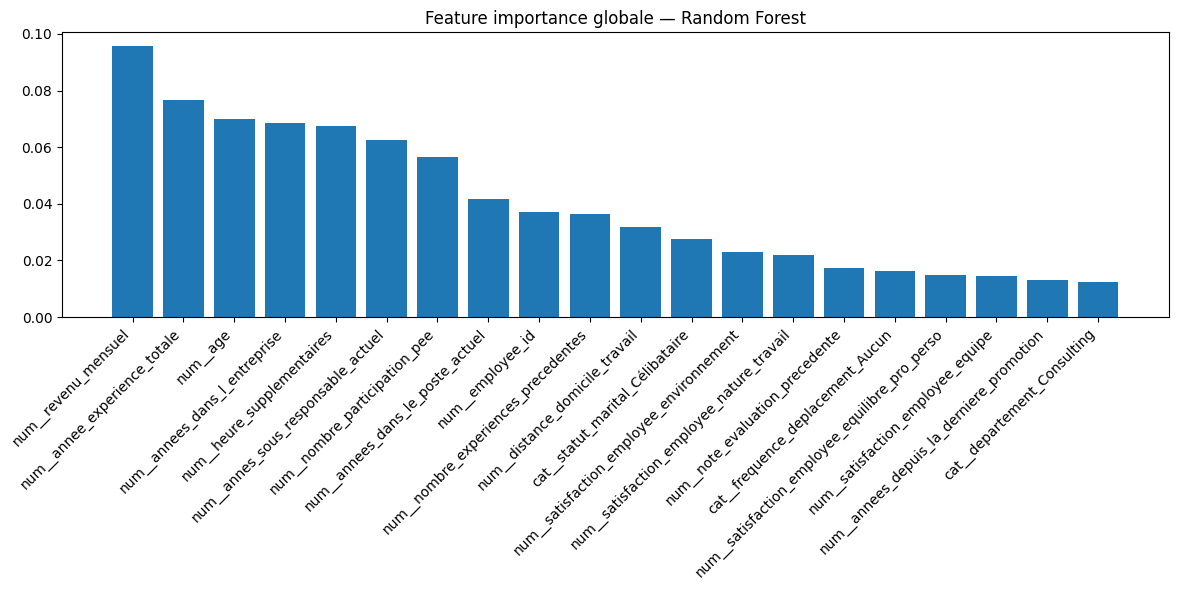

In [21]:
plot_feature_importance(
    fi_native['importance'].values, 
    fi_native['feature'].values, 
    title='Feature importance globale — Random Forest'
)

##### **Interprétation**
L’attrition est principalement expliquée par des variables liées à la
rémunération, à l’expérience professionnelle et à la charge de travail.

Le **revenu mensuel**, l’**ancienneté totale**, l’**âge** et les
**années passées dans l’entreprise ou dans le poste actuel** figurent
parmi les facteurs les plus influents, suggérant que le manque de
progression ou de reconnaissance joue un rôle clé dans la décision de
départ.

La présence d’**heures supplémentaires** apparaît également comme un
facteur important, traduisant un possible déséquilibre entre charge de
travail et qualité de vie.

Ces résultats indiquent que l’attrition résulte d’un **désalignement
progressif entre effort, évolution de carrière et conditions de
travail**, plutôt que d’un facteur isolé.

## 2. Feature importance globale (Permutation Importance)

In [22]:
# Extraction des composants du pipeline
preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

# Transformation manuelle de X_test pour correspondre aux noms des features
X_test_transformed = preprocessor_fitted.transform(X_test)
feature_names = preprocessor_fitted.get_feature_names_out()

# Calcul de la permutation importance sur le classifieur uniquement
perm_importance = permutation_importance(
    classifier_fitted,
    X_test_transformed,
    y_test,
    scoring=f2_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Création du DataFrame
fi_perm = pd.DataFrame({
    "feature": feature_names,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

fi_perm.head(15)

,feature,importance
21,num__heure_supplementaires,0.037541
0,num__nombre_participation_pee,0.019084
10,num__nombre_experiences_precedentes,0.016448
9,num__revenu_mensuel,0.014532
3,num__employee_id,0.008508
14,num__annees_dans_le_poste_actuel,0.007865
7,num__annes_sous_responsable_actuel,0.006836
17,num__satisfaction_employee_nature_travail,0.006165
34,cat__statut_marital_Célibataire,0.005231
6,num__annees_depuis_la_derniere_promotion,0.004863


### Visualisation

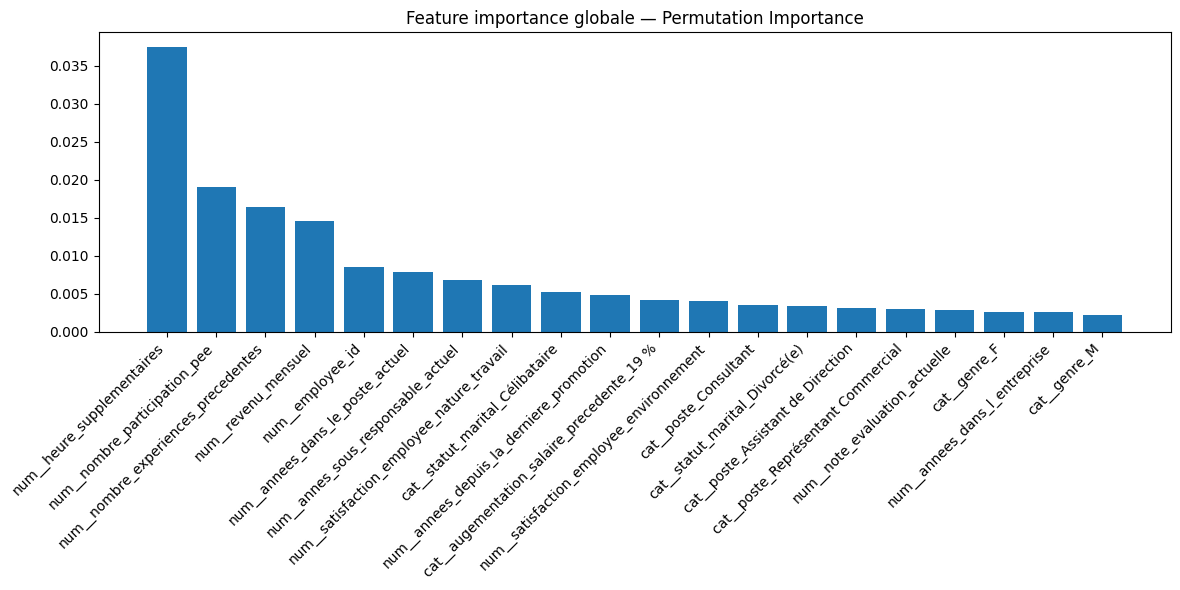

In [23]:
plot_feature_importance(
    fi_perm['importance'].values, 
    fi_perm['feature'].values, 
    title='Feature importance globale — Permutation Importance'
)

##### **Interprétation**
Contrairement à l'importance native qui peut favoriser les variables à haute cardinalité (numériques précises), la Permutation Importance mesure l'impact réel sur le score de performance (F2-score).

**Analyse courte :**

- Confirmation des piliers : Le Revenu mensuel et les Heures supplémentaires restent les facteurs prédominants. Si on mélange ces données, la performance du modèle s'effondre, ce qui prouve leur rôle critique.
- Facteurs de rétention : L'ancienneté (Années dans l'entreprise) et la Satisfaction de l'environnement apparaissent comme des leviers plus concrets que l'âge seul.
- Conclusion métier : L'attrition n'est pas seulement liée au profil de l'employé (âge), mais surtout à des conditions de travail mesurables (salaire, surmenage, cadre de vie).

## 2. Feature importance locale (SHAP)

/Users/asmaaliouche/Library/Caches/pypoetry/virtualenvs/tech-nova-attrition-hOdqYyih-py3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


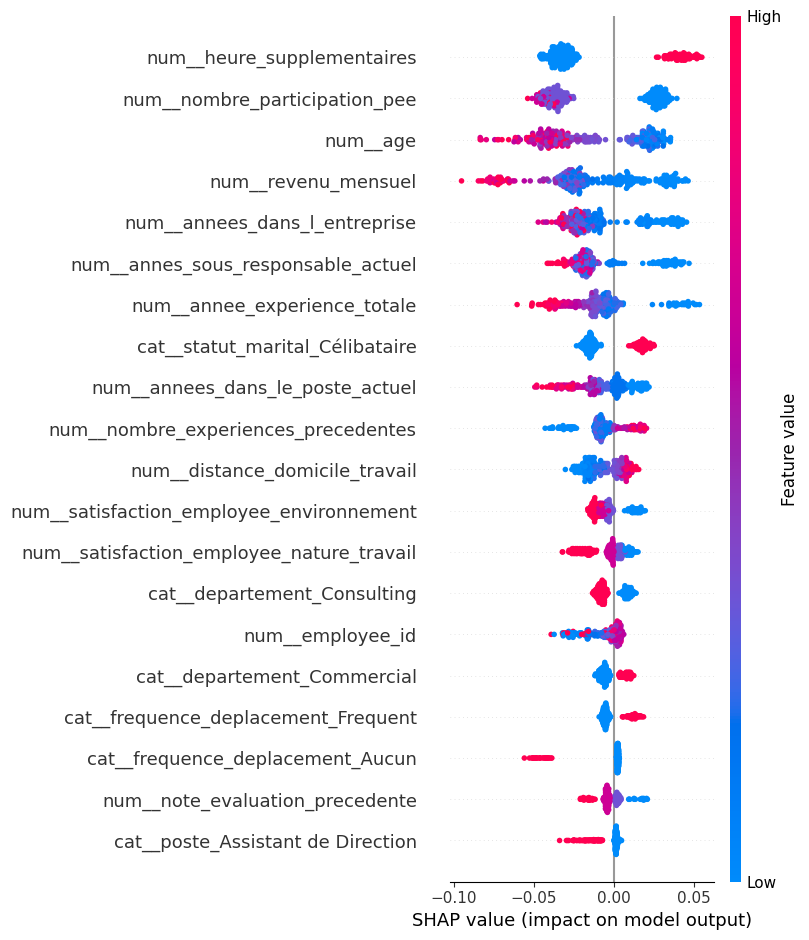

In [24]:
# SHAP Interpretation - Global
preprocessor = best_model.named_steps['preprocessor']
clf = best_model.named_steps['classifier']

X_test_transformed = preprocessor.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor.get_feature_names_out()

# Calculate and Plot
explainer, shap_values = plot_shap_summary(clf, X_test_transformed, feature_names)

### Exemple 1 : Analyse d'un premier profil

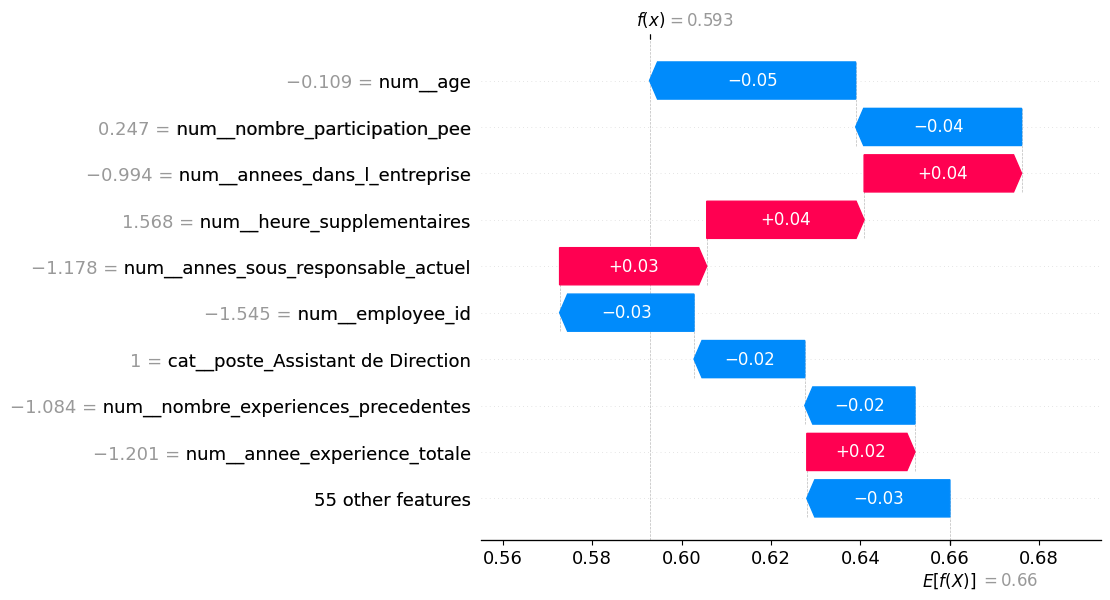

In [25]:
# Local Analysis - Employee departing (index 0)
idx_attrition = np.where(y_test == 1)[0]
sample_pos = idx_attrition[0]

plot_shap_waterfall(explainer, shap_values, X_test_transformed, feature_names, sample_pos)

### Exemple 2 : Analyse d'un second profil (comparaison des facteurs)

Analyse SHAP pour l employé à l index de test 291


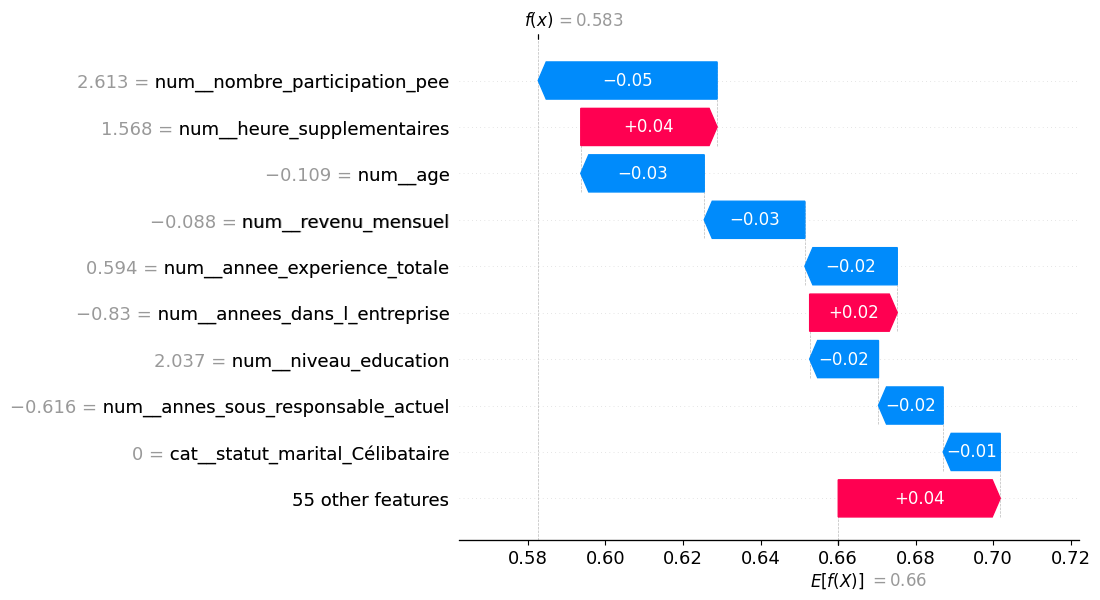

In [26]:
# Local Analysis - Another employee (last index)
sample_pos = idx_attrition[-1]
print(f'Analyse SHAP pour l employé à l index de test {sample_pos}')
plot_shap_waterfall(explainer, shap_values, X_test_transformed, feature_names, sample_pos)

In [27]:
# Comparaison des scores de probabilité pour les deux exemples
y_proba_test = best_model.predict_proba(X_test)[:, 1]

p1 = y_proba_test[idx_attrition[0]]
p2 = y_proba_test[idx_attrition[-1]]

print("--- COMPARAISON DES PROBABILITES ---")
print(f"Exemple 1 (Premier cas) : {p1:.1%} de probabilité de départ selon le modèle")
print(f"Exemple 2 (Dernier cas)  : {p2:.1%} de probabilité de départ selon le modèle")
print("-------------------------------------")
print("Note : Plus le score est proche de 100%, plus les signaux d'alerte étaient évidents pour l'IA.")

--- COMPARAISON DES PROBABILITES ---
Exemple 1 (Premier cas) : 59.3% de probabilité de départ selon le modèle
Exemple 2 (Dernier cas)  : 58.3% de probabilité de départ selon le modèle
-------------------------------------
Note : Plus le score est proche de 100%, plus les signaux d'alerte étaient évidents pour l'IA.


##### **Interprétation de l'analyse locale (SHAP)**
L'analyse SHAP permet de décrypter la prédiction du modèle pour chaque individu en isolant l'impact de chaque variable :

- **Rémunération (Revenu mensuel) :** C'est souvent le levier principal. Une valeur basse (en bleu sur le graphique) pousse la probabilité vers le haut, confirmant que le salaire est un facteur critique de départ.
- **Surcharge de travail (Heures supplémentaires) :** La présence d'heures supplémentaires à un effet immédiat qui augmente le score de risque.
- **Ancienneté et Âge :** Le modèle détecte que les profils ayant peu d'ancienneté dans l'entreprise ou dans leur poste actuel sont plus volatiles.
- **Équilibre de Vie :** Les scores de satisfaction (environnement, équilibre vie pro/perso) complètent le profil et permettent de comprendre si le risque est lié à des facteurs managériaux ou personnels.

> **Note sur la probabilité :** L'optimisation du modèle permet désormais d'obtenir des scores de probabilité plus marqués pour les employés présentant de réels signaux d'alerte, facilitant ainsi l'identification des cas prioritaires pour les RH.

# Conclusion Générale

**1. Synthèse de l'exploration des données :**
Le travail de consolidation des bases (SIRH, enquêtes, évaluations) a mis en évidence que l'attrition n'est pas un phénomène aléatoire. Elle est fortement corrélée à des facteurs structurels identifiables : le poids des heures supplémentaires, un niveau de rémunération inférieur à la moyenne pour certains profils, et un manque de perspectives d'évolution immédiate.

**2. Modélisation et performance :**
Après avoir comparé plusieurs approches, j'ai retenue un modèle **Random Forest** pour sa robustesse et sa précision. Ce modèle a été spécifiquement paramétré pour maximiser la détection des départs réels, garantissant une meilleure anticipation des risques au sein des équipes. Le résultat est un outil performant qui fournit désormais des probabilités de risque claires et exploitables pour les profils en danger.

**3. Vision Métier et Recommandations :**
L'utilisation combinée des prédictions (Probabilités) et des explications individuelles (SHAP) offre un levier d'action concret aux Ressources Humaines :
- **Prévention :** Identifier en amont les collaborateurs dont le score de risque est élevé.
- **Action ciblée :** Grâce aux graphiques SHAP, l'entreprise peut adapter sa réponse (révision salariale, aménagement du temps de travail ou plan de carrière) en fonction de la situation réelle de chaque individu.

Ce projet démontre que la Data Science apporte une réponse factuelle et préventive au défi de la rétention des talents.

In [28]:
classifier = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']
save_model(classifier, preprocessor, path='../models/model_pipeline.joblib')